# 3D PyBaMM Pouch Cell Modelling Tool

A 3D electrochemical-thermal model of a **9 Ah lithium-ion pouch cell** built from **20 stacks of electrodes and separators**.

| Design | Value |
|---|---|
| Positive electrode | **NCM811** (LiNi0.8Co0.1Mn0.1O2) |
| Negative electrode | **graphite** |
| Capacity | 9 Ah (electrodes auto-sized) |
| Footprint | **15 cm (z) x 9 cm (y)** |
| Outer thickness | **1 cm** (incl. packaging) |
| Stack | 20 electrode pairs in parallel |

The 20 parallel layers are represented through PyBaMM's parameter `Number of electrodes connected in parallel to make a cell = 20`, which scales the current-collector area so current densities and capacity match a real 20-stack pouch (see `pouch_cell/cell_spec.py` and the README).

In [1]:
import matplotlib.pyplot as plt
import pybamm

from pouch_cell import PouchCellSpec, PouchCellSimulation, plotting

pybamm.set_logging_level("ERROR")

## 1. Cell design

`PouchCellSpec` describes the whole pouch cell. Electrode thicknesses are **auto-sized** so the cell delivers the requested 9 Ah (a fast 1D reference discharge is used to converge the thicknesses).

In [2]:
spec = PouchCellSpec()
print(spec.report())

Pouch cell design:  graphite / NCM811
  Footprint        : 15 cm (z) x 10 cm (y)
  Outer thickness  : 7.0 mm (1 cm, incl. packaging)
  Active stack     : 2.0 mm (10 pairs x 222.0 um unit cell)
  Packaging margin : 4.9 mm
  Stacks in parallel: 10   |  series cells: 1
  Nominal capacity : 9.00 Ah
  Total area       : 1500 cm^2 (= 10 x 150 cm^2)
  Areal capacity   : 6.00 mAh/cm^2 (over the whole stack)


## 2. The 20-stack architecture

A schematic cross-section of the stack (each pair = graphite electrode / separator / NCM811 electrode, connected in parallel).

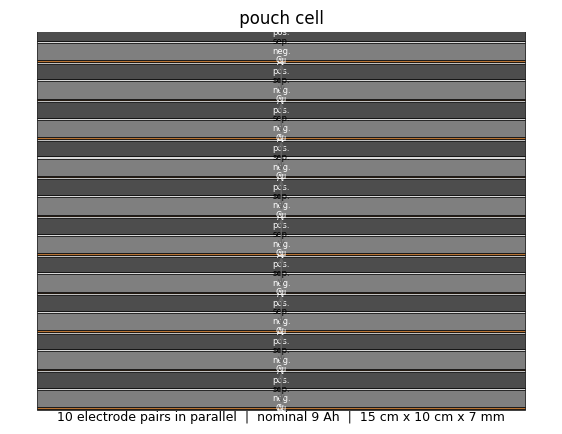

In [3]:
plotting.stack_diagram(spec, max_layers=30)
plt.title(" pouch cell ")
plt.show()

## 3. Fast 1D calibration: the cell delivers 9 Ah

A quick 1D **DFN** discharge confirms the auto-sized electrodes deliver the target capacity to the 2.5 V cut-off (runs in ~1-2 seconds).  DFN is the most detailed electrochemical model (full electrolyte transport); it is the tool's default everywhere.


In [4]:
sim1d = PouchCellSimulation(spec, model_name="DFN", dimensionality=0,
                            thermal="lumped", mesh="draft")
sol1d = sim1d.discharge(C_rate=1.0)
print(sim1d.summary())
print(f"\nDelivered capacity: {sim1d.discharge_capacity_Ah():.2f} Ah")


  [sizing 1/8] L_n = 100.0 um, L_p = 90.0 um -> delivers 8.53 Ah (target 9.00 Ah, scale 1.055)
  [sizing 2/8] L_n = 105.5 um, L_p = 95.0 um -> delivers 9.01 Ah (target 9.00 Ah, scale 0.999)
Pouch cell design:  graphite / NCM811
  Footprint        : 15 cm (z) x 10 cm (y)
  Outer thickness  : 7.0 mm (1 cm, incl. packaging)
  Active stack     : 2.1 mm (10 pairs x 232.5 um unit cell)
  Packaging margin : 4.8 mm
  Stacks in parallel: 10   |  series cells: 1
  Nominal capacity : 9.00 Ah
  Total area       : 1500 cm^2 (= 10 x 150 cm^2)
  Areal capacity   : 6.00 mAh/cm^2 (over the whole stack)
  Electrode capacity (max): 10.54 Ah (neg) / 16.02 Ah (pos)
  -> capacity-limiting electrode: negative
  -> ratio nominal/limiting: 0.85
  Electrode sizing  : L_n = 105.5 um, L_p = 95.0 um (delivered 9.01 Ah at 1C)
  Model            : DFN (dimensionality 0, thermal 'lumped')
  Discharge        : 4.043 V -> 2.500 V | 9.024 Ah | T = 298.1 K -> 308.5 K

Delivered capacity: 9.02 Ah


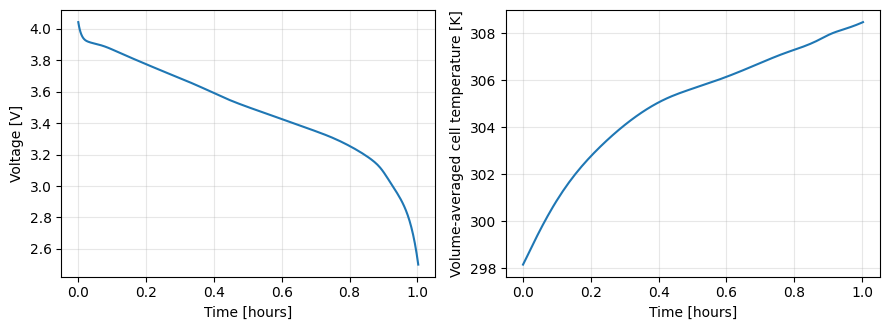

In [5]:
fig = plotting.plot_discharge(sol1d, spec)
plt.show()

> Note: `SPM_3D` uses **SPM** electrochemistry (there is no genuine-3D DFN in PyBaMM), so for the electrochemical behaviour prefer the 2+1D DFN/SPMe models; this model is for fast, genuine-3D *thermal* fields.


In [6]:
sim3 = PouchCellSimulation(spec, model_name="SPM_3D", mesh="draft")
sol3 = sim3.discharge(C_rate=1.0, duration_s=3600)
print(sim3.summary())

  [sizing 1/8] L_n = 100.0 um, L_p = 90.0 um -> delivers 8.53 Ah (target 9.00 Ah, scale 1.055)
  [sizing 2/8] L_n = 105.5 um, L_p = 95.0 um -> delivers 9.01 Ah (target 9.00 Ah, scale 0.999)
Pouch cell design:  graphite / NCM811
  Footprint        : 15 cm (z) x 10 cm (y)
  Outer thickness  : 7.0 mm (1 cm, incl. packaging)
  Active stack     : 2.1 mm (10 pairs x 232.5 um unit cell)
  Packaging margin : 4.8 mm
  Stacks in parallel: 10   |  series cells: 1
  Nominal capacity : 9.00 Ah
  Total area       : 1500 cm^2 (= 10 x 150 cm^2)
  Areal capacity   : 6.00 mAh/cm^2 (over the whole stack)
  Electrode capacity (max): 10.54 Ah (neg) / 16.02 Ah (pos)
  -> capacity-limiting electrode: negative
  -> ratio nominal/limiting: 0.85
  Electrode sizing  : L_n = 105.5 um, L_p = 95.0 um (delivered 9.01 Ah at 1C)
  Model            : SPM_3D (dimensionality 3, thermal 'x-lumped')
  Discharge        : 4.081 V -> 2.630 V | 9.000 Ah | T = 298.2 K -> 299.0 K


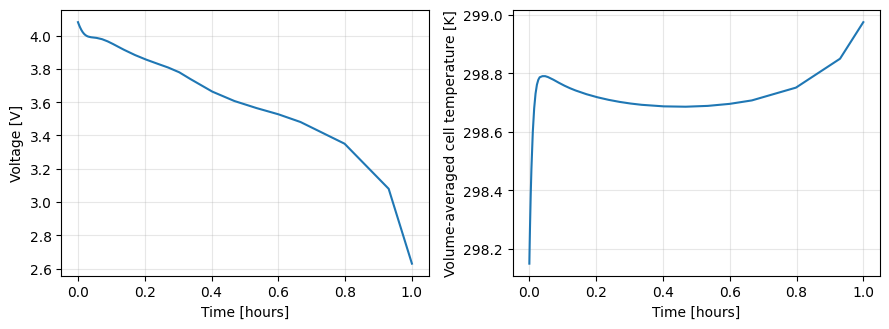

3D temperature field: (1302, 42) (FEM nodes x time steps)
temperature range: 298.15 .. 298.98 K


In [7]:
# voltage + average temperature
fig = plotting.plot_discharge(sol3, spec)
plt.show()

T = sol3["Cell temperature [K]"]
print(f"3D temperature field: {T.entries.shape} (FEM nodes x time steps)")
print(f"temperature range: {T.entries.min():.2f} .. {T.entries.max():.2f} K")

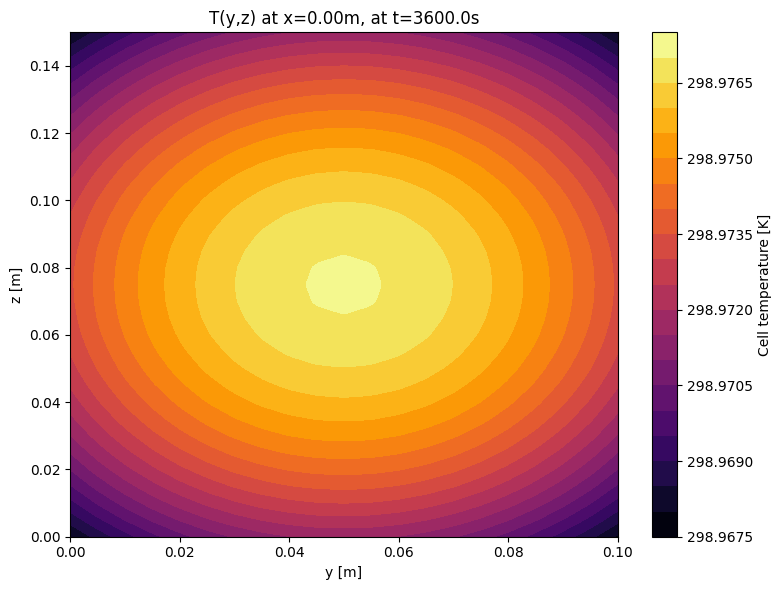

In [8]:
# 3D slice through the cell at the final time (through width-height plane)
fig = plotting.plot_3d_cross_section(sol3, variable="Cell temperature [K]",
                                     plane="yz", position=0.5)
plt.show()

## 5. The 2+1D electrochemical "3D pouch" models (DFN default)

The 2+1D models (`SPM` / `SPMe` / `DFN` with `dimensionality=2`) resolve the through-plane coordinate plus the in-plane current collectors with the full potential pair, giving 3D **current and voltage** distributions. **`DFN` is the default everywhere** -- it is the most detailed electrochemistry (full electrolyte transport in both electrodes), so it is the physically complete choice (the fast `SPM` shortcut omits electrolyte transport and shows a voltage-collapse / inflated-temperature artifact in 2+1D; `SPMe` is the reduced-order intermediate). The cost is runtime: 2+1D DFN takes minutes per minute of simulated discharge, so the tab-analysis section (below) uses a coarse mesh and a short discharge. A direct example:

```python
sim21 = PouchCellSimulation(spec)                 # defaults to DFN, dim=2
sol21 = sim21.discharge(C_rate=1.0, duration_s=60)  # slow
plotting.plot_current_density_map(sol21)
plotting.plot_temperature_map(sol21)
```


The **2+1D DFN model** (potential-pair current collectors + `x-lumped` thermal) captures exactly this -- and because it is DFN it resolves the **full electrolyte transport** that the fast SPM shortcut omits (SPMe approximates it with a reduced profile), so the temperature is physical (no voltage-collapse artifact). The trade-off is runtime: 2+1D DFN takes minutes per minute of simulated discharge, so this cell uses the smallest mesh and a short 5 s discharge (the 2+1D DAE cannot integrate beyond ~5-10 s).

`tab_heating_analysis()` plots the four panels: the in-plane current density in each current collector (computed from `|i_cc| = sigma * |grad phi_cc|`), the total current-collector Ohmic heating `Q = i^2/sigma`, and the resulting x-lumped temperature field -- tab positions are marked in red.


Pouch cell design:  graphite / NCM811
  Footprint        : 15 cm (z) x 10 cm (y)
  Outer thickness  : 7.0 mm (1 cm, incl. packaging)
  Active stack     : 2.0 mm (10 pairs x 222.0 um unit cell)
  Packaging margin : 4.9 mm
  Stacks in parallel: 10   |  series cells: 1
  Nominal capacity : 9.00 Ah
  Total area       : 1500 cm^2 (= 10 x 150 cm^2)
  Areal capacity   : 6.00 mAh/cm^2 (over the whole stack)
  Electrode capacity (max): 9.99 Ah (neg) / 15.18 Ah (pos)
  -> capacity-limiting electrode: negative
  -> ratio nominal/limiting: 0.90
  Model            : DFN (dimensionality 2, thermal 'x-lumped')
  Discharge        : 3.562 V -> 3.452 V | 0.013 Ah | T = 298.1 K -> 303.1 K


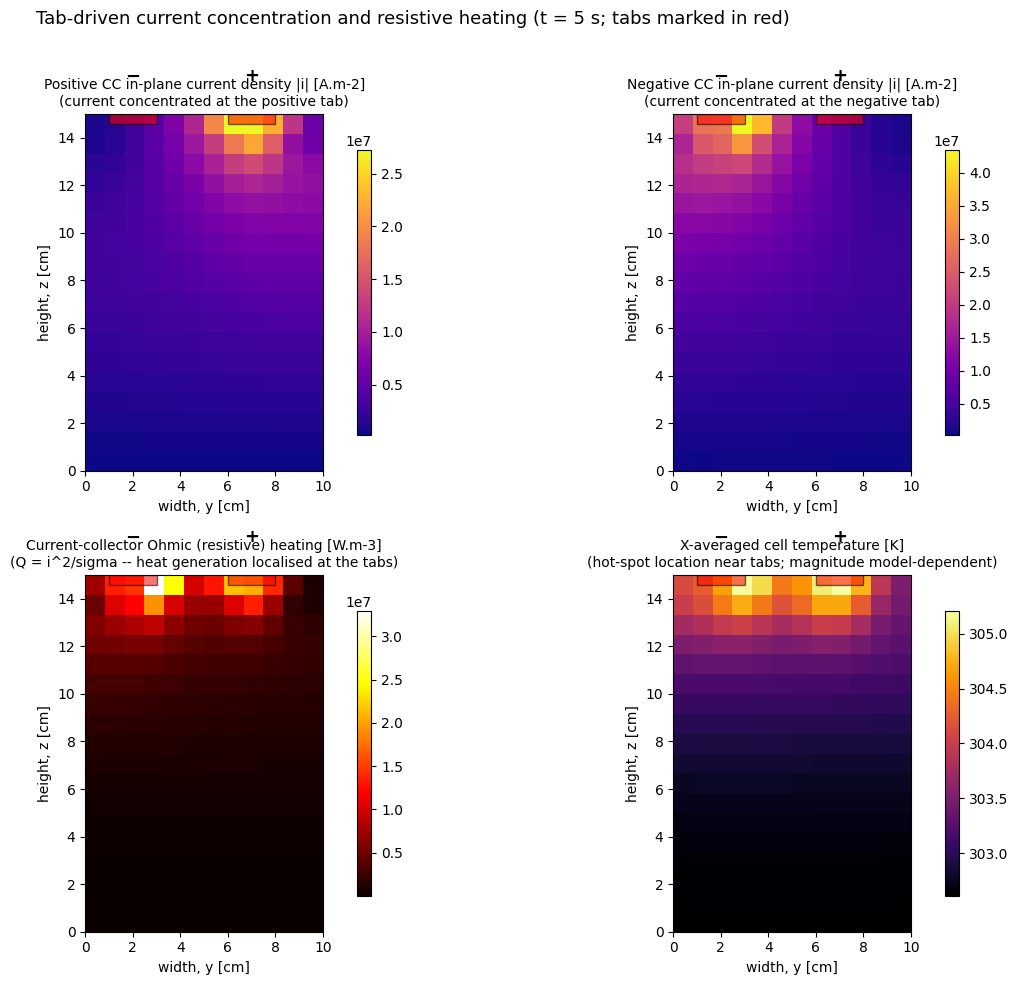

In [9]:
# 2+1D DFN tab-aware analysis (small 2x-density mesh, uniform-profile particles).
# NOTE: solver choice does not speed up DFN/SPMe 2+1D -- the mesh and duration
# do.  * duration <= 5 s: completes in ~1 min (2x mesh density, IDAKLU solver)
#   * duration > ~10 s: hits SolverError: IDA_ERR_FAIL (DAE min step size)
#   * pybamm.CasadiSolver is deprecated in PyBaMM 26.8 and is no faster here
# For longer runs use SPM 2+1D (fast) or SPM_3D instead.
sim_tab, sol_tab, fig_tab = PouchCellSimulation.tab_heating_analysis(
    spec,
    C_rate=1.0,
    duration_s=5,
    mesh="micro_21d",
)
print(sim_tab.summary())
plt.show()


### Tab analysis beyond 5 s

The DFN/SPMe 2+1D DAE hits a hard numerical wall at ~5-10 s of 1C discharge (`IDA_ERR_FAIL` minimum step size) -- no solver setting, thermal submodel, mesh size or step-chaining gets past it.  The tab current-concentration is a transient visible within the first seconds, so the 5 s DFN run above captures the full spatial picture.

To see how the tab hot-spot **develops over 60 s+**, use the **same potential-pair architecture with SPM electrochemistry** (`model_name="SPM"`): it has no electrolyte transport, so it runs 60 s in about a second.

> Caveat: SPM omits electrolyte transport, so its temperature **magnitudes** are inflated (hot-spot *locations* are correct) -- use it for the long-time spatial trend, not quantitative temperatures.


Pouch cell design:  graphite / NCM811
  Footprint        : 15 cm (z) x 10 cm (y)
  Outer thickness  : 7.0 mm (1 cm, incl. packaging)
  Active stack     : 2.0 mm (10 pairs x 222.0 um unit cell)
  Packaging margin : 4.9 mm
  Stacks in parallel: 10   |  series cells: 1
  Nominal capacity : 9.00 Ah
  Total area       : 1500 cm^2 (= 10 x 150 cm^2)
  Areal capacity   : 6.00 mAh/cm^2 (over the whole stack)
  Electrode capacity (max): 9.99 Ah (neg) / 15.18 Ah (pos)
  -> capacity-limiting electrode: negative
  -> ratio nominal/limiting: 0.90
  Model            : SPM (dimensionality 2, thermal 'x-lumped')
  Discharge        : 3.845 V -> 1.500 V | 0.900 Ah | T = 298.2 K -> 317.5 K
t span: 0 .. 360 s | T: 298.2 -> 317.5 K


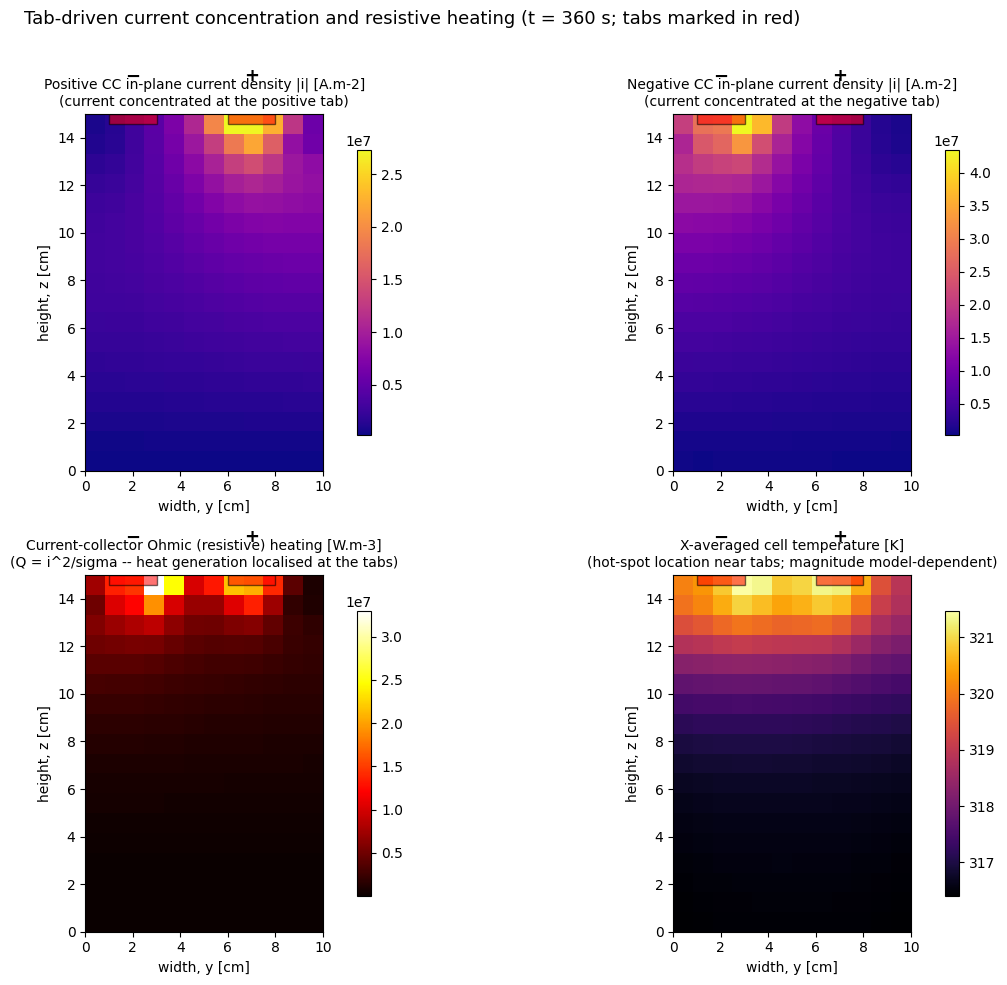

In [10]:
# Long-time tab hot-spot development: SPM 2+1D, 60 s of 1C discharge.
# Runs in ~1-2 s.  NOTE: SPM temperature magnitudes are inflated (DFN/SPMe
# cannot run this long) -- treat the temperature as a spatial trend, not a number.
sim_tab60, sol_tab60, fig_tab60 = PouchCellSimulation.tab_heating_analysis(
    spec,
    C_rate=1.0,
    duration_s=3600,
    mesh="micro_21d",
    model_name="SPM",
)
print(sim_tab60.summary())
print(f"t span: {sol_tab60['Time [s]'].entries[0]:.0f} .. "
      f"{sol_tab60['Time [s]'].entries[-1]:.0f} s | "
      f"T: {sol_tab60['Volume-averaged cell temperature [K]'].entries[0]:.1f} -> "
      f"{sol_tab60['Volume-averaged cell temperature [K]'].entries[-1]:.1f} K")
plt.show()


## 7. Thermal dissipation & active cooling

Dissipation is modelled with Newton's law of cooling `Q = h * A * (T - T_amb)` using a uniform heat-transfer coefficient `h` (default 5 W/m2/K, natural convection) and a uniform ambient temperature.  The **`cooling=`** option on `PouchCellSimulation` wraps the underlying parameters:

- **preset strings**: `"natural"` (h=5), `"forced_air"`/`"fan"` (h=50), `"liquid_cold_plate"`/`"cold_plate"` (h=500);
- **a dict**: `heat_transfer_coefficient_W_m2K` and `ambient_temperature_K` convenience keys, **plus any PyBaMM parameter override** -- e.g. per-face coefficients for the true-3D model (`"bottom"`/`"top"` aliases) or a time-dependent coolant `{"Ambient temperature [K]": lambda t: 288.15 if t < 600 else 298.15}`.

The cell below verifies the wiring and compares natural vs forced-air cooling on a 1D discharge.


In [11]:
# Force a fresh re-import so the new cooling= option is picked up.
import sys
for _name in [n for n in list(sys.modules) if n.startswith("pouch_cell")]:
    del sys.modules[_name]
import pouch_cell.cell_spec, pouch_cell.parameters
import pouch_cell.model, pouch_cell.simulation, pouch_cell.plotting
from pouch_cell.cell_spec import PouchCellSpec
from pouch_cell.simulation import PouchCellSimulation
spec = PouchCellSpec()

# 1) preset: forced-air active cooling (uniform h = 50 W/m2/K)
sim_cool = PouchCellSimulation(spec, cooling="forced_air")
print("forced_air: h =",
      sim_cool.param["Total heat transfer coefficient [W.m-2.K-1]"],
      "W/m2/K")

# 2) dict: chilled coolant + a cold plate on the bottom face (true-3D model)
sim_plate = PouchCellSimulation(
    spec, model_name="SPM_3D", mesh="draft",
    cooling={"ambient_temperature_K": 288.15, "bottom": 500.0, "top": 5.0},
)
print("cold plate: T_amb =",
      sim_plate.param["Ambient temperature [K]"],
      "| bottom h =",
      sim_plate.param["Bottom face heat transfer coefficient [W.m-2.K-1]"],
      "| top h =",
      sim_plate.param["Top face heat transfer coefficient [W.m-2.K-1]"])

# 3) 1D comparison: natural vs forced-air temperature rise (1C, 600 s)
for label, cooling in [("natural", None), ("forced_air", "forced_air")]:
    s = PouchCellSimulation(spec, model_name="DFN", dimensionality=0,
                            thermal="lumped", mesh="draft",
                            cooling=cooling, size_to_capacity=False)
    sol = s.discharge(C_rate=1.0, duration_s=600)
    T = sol["Volume-averaged cell temperature [K]"].entries
    print(f"{label:10s}: T {T[0]:.1f} -> {T[-1]:.1f} K")


  [sizing 1/8] L_n = 100.0 um, L_p = 90.0 um -> delivers 8.53 Ah (target 9.00 Ah, scale 1.055)
  [sizing 2/8] L_n = 105.5 um, L_p = 95.0 um -> delivers 9.01 Ah (target 9.00 Ah, scale 0.999)
forced_air: h = 50.0 W/m2/K
  [sizing 1/8] L_n = 100.0 um, L_p = 90.0 um -> delivers 8.53 Ah (target 9.00 Ah, scale 1.055)
  [sizing 2/8] L_n = 105.5 um, L_p = 95.0 um -> delivers 9.01 Ah (target 9.00 Ah, scale 0.999)
cold plate: T_amb = 288.15 | bottom h = 500.0 | top h = 5.0
natural   : T 298.1 -> 302.2 K
forced_air: T 298.1 -> 299.1 K


natural   : final hot-spot T = 319.8 K
forced_air: final hot-spot T = 301.5 K


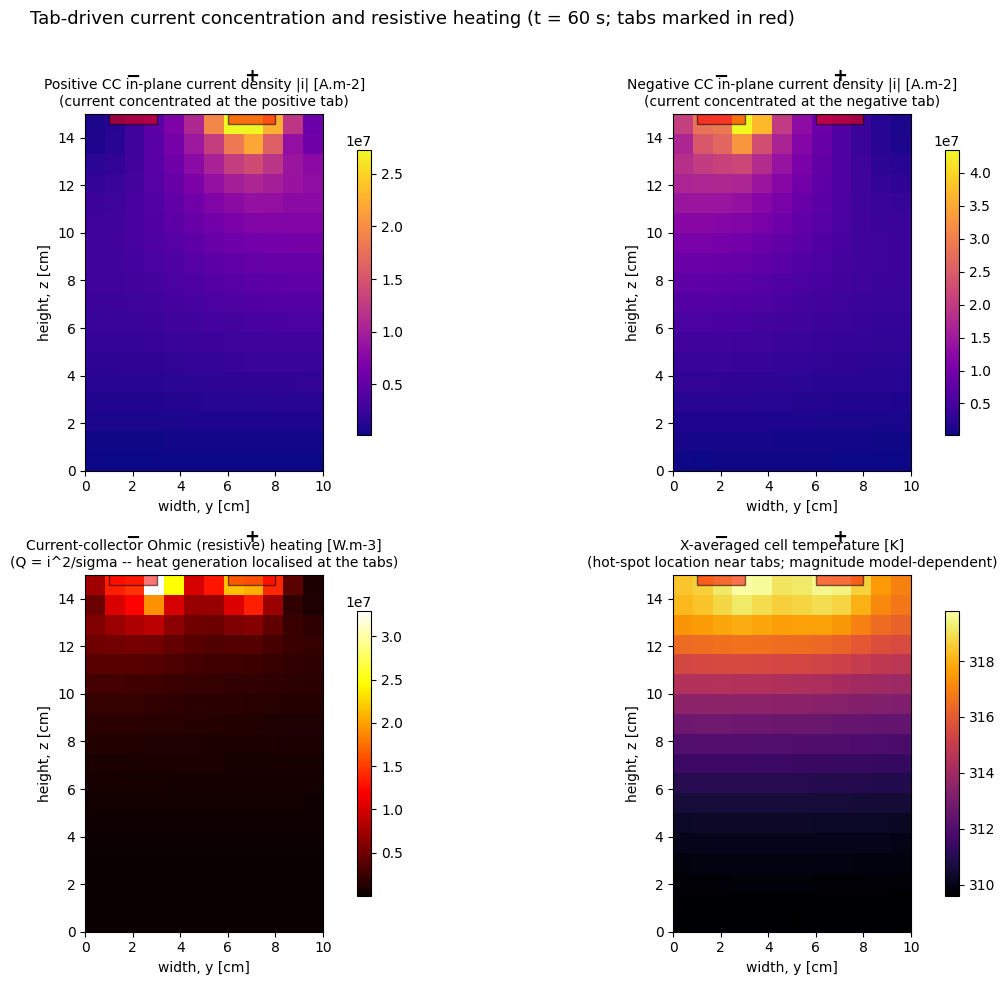

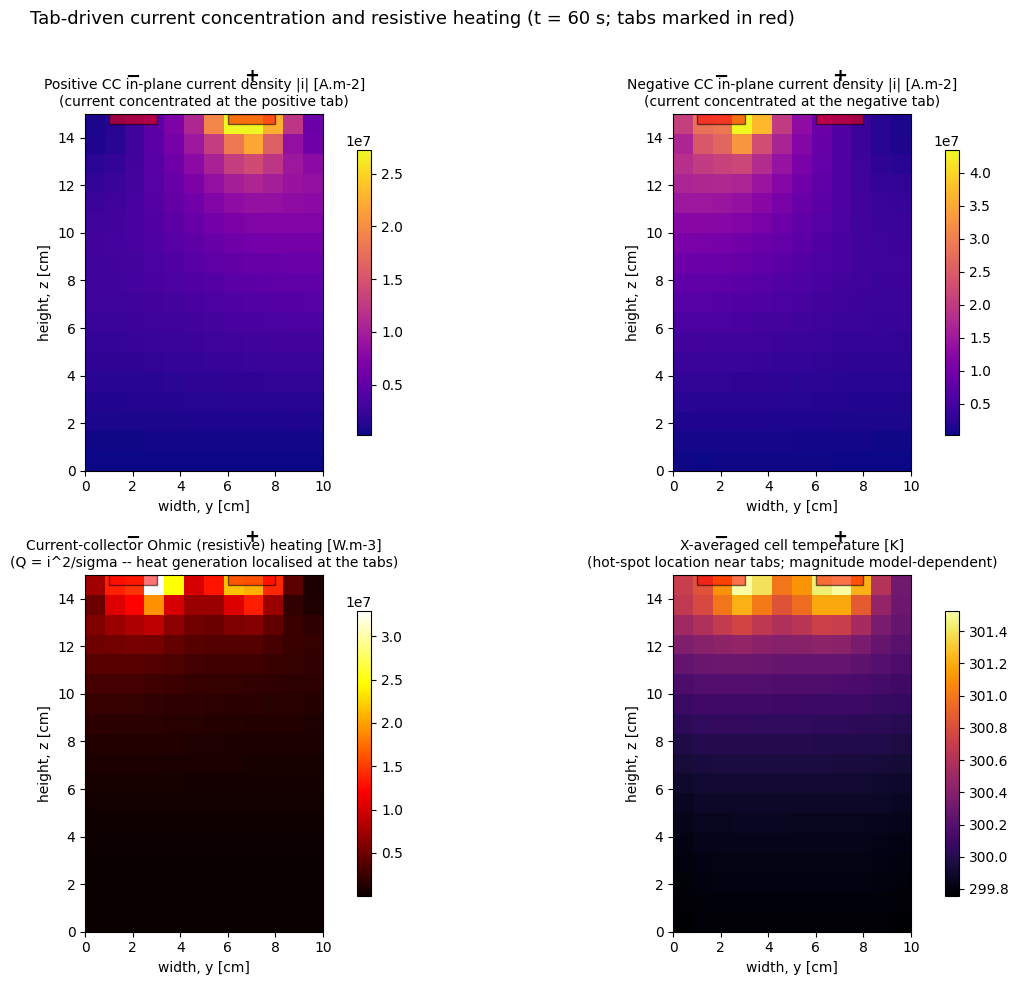

In [12]:
# Tab hot-spots under active cooling: SPM 2+1D long-time run (60 s),
# comparing natural convection vs forced-air cooling.  `cooling=` is passed
# straight through to the tab analysis (applied to the x-lumped thermal).
for label, cooling in [("natural", None), ("forced_air", "forced_air")]:
    sim_c, sol_c, fig_c = PouchCellSimulation.tab_heating_analysis(
        spec, C_rate=1.0, duration_s=60, mesh="micro_21d",
        model_name="SPM", cooling=cooling,
    )
    Tmap = sol_c["X-averaged cell temperature [K]"].entries
    print(f"{label:10s}: final hot-spot T = {Tmap[..., -1].max():.1f} K")
plt.show()


no pipe   : hot-spot 321.5 K | T@neg-tab 320.8 K | T@pos-tab 321.3 K
heat pipe : hot-spot 315.9 K | T@neg-tab 300.4 K | T@pos-tab 300.9 K


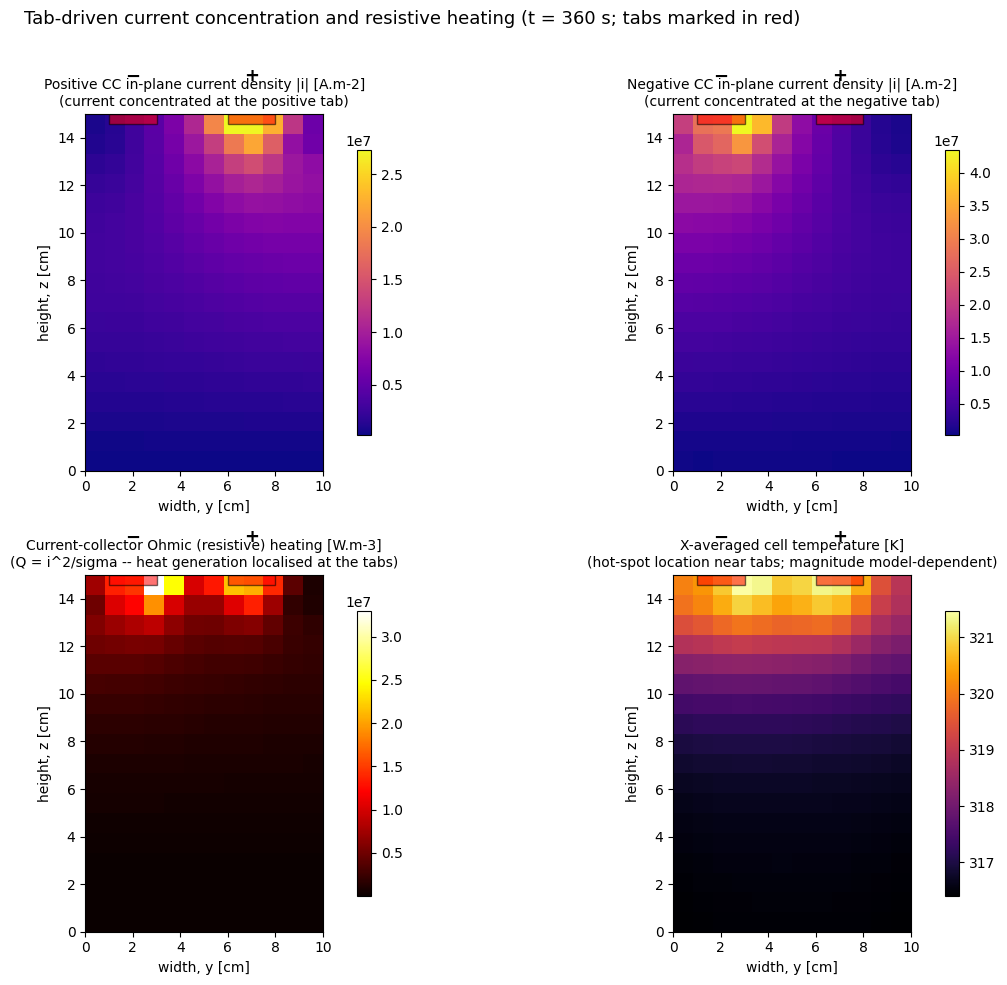

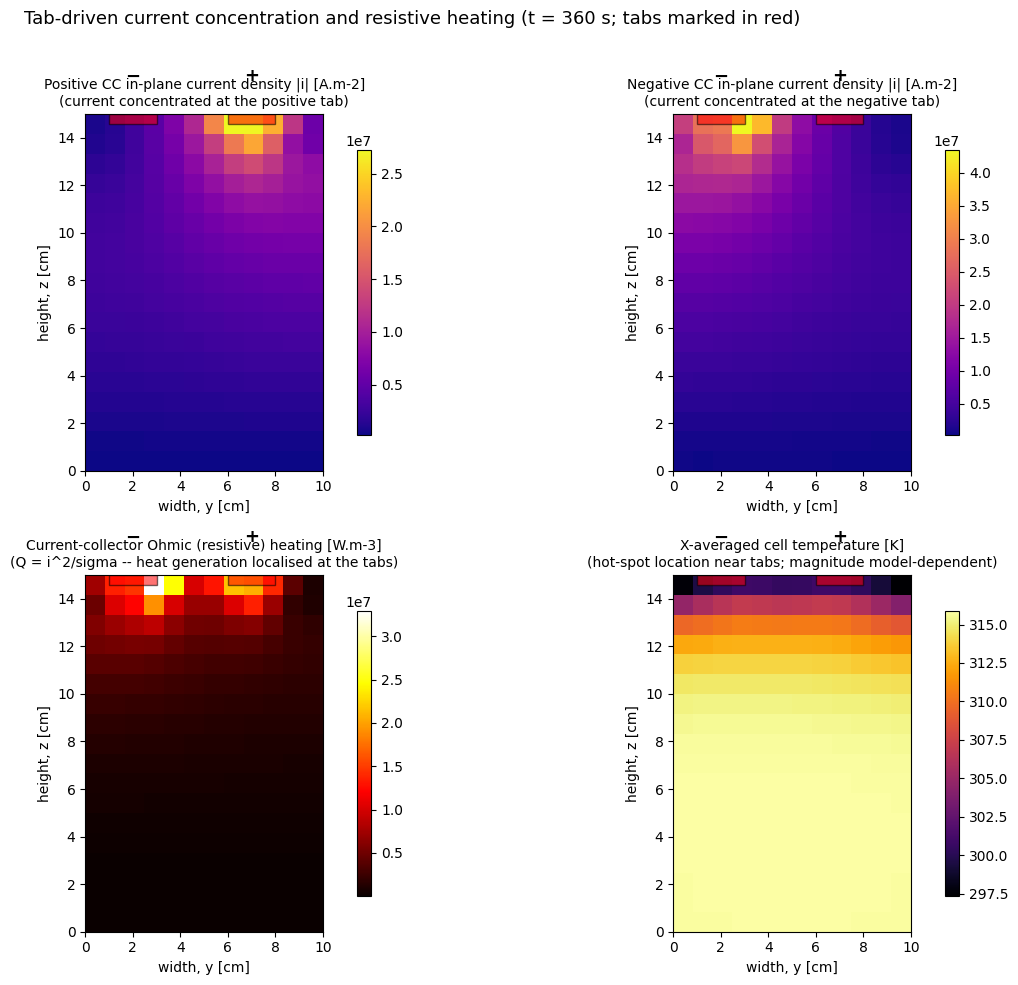

In [13]:
# Heat-pipe cooling: a full-width copper heat pipe runs across the cell width,
# right below the top edge (0.5 cm-tall band, 288 K), beside both tabs; the
# folded tabs + thermal paste + pipe are lumped into h = 2000 W/m2/K.  Compare
# the SPM 2+1D tab hot-spot with and without the pipe (60 s of 1C).  Fresh
# re-import so the kernel picks up the new PouchCellSpec heat-pipe fields.
import sys
for _name in [n for n in list(sys.modules) if n.startswith("pouch_cell")]:
    del sys.modules[_name]
import matplotlib.pyplot as plt
import pouch_cell.cell_spec, pouch_cell.parameters
import pouch_cell.model, pouch_cell.simulation, pouch_cell.plotting
from pouch_cell.cell_spec import PouchCellSpec
from pouch_cell.simulation import PouchCellSimulation
from dataclasses import replace
import numpy as np
spec = PouchCellSpec()

for label, enabled in [("no pipe", False), ("heat pipe", True)]:
    spec_hp = replace(spec, heat_pipe_enabled=enabled)
    sim_hp, sol_hp, fig_hp = PouchCellSimulation.tab_heating_analysis(
        spec_hp, C_rate=1.0, duration_s=3600, mesh="micro_21d", model_name="SPM")
    Tmap = sol_hp["X-averaged cell temperature [K]"].entries
    y = np.asarray(sol_hp["y [m]"].entries)[:, 0, 0]   # (n_y,)
    z = np.asarray(sol_hp["z [m]"].entries)[0, :, 0]   # (n_z,)
    Tf = Tmap[..., -1]  # (n_y, n_z)
    Tmax = Tf.max()
    # temperature right at each tab on the top edge
    def tab_T(yc):
        iy = int(np.argmin(np.abs(y - yc)))
        iz = int(np.argmin(np.abs(z - spec.height)))
        return Tf[iy, iz]
    print(f"{label:10s}: hot-spot {Tmax:.1f} K | "
          f"T@neg-tab {tab_T(spec.neg_tab_y_centre):.1f} K | "
          f"T@pos-tab {tab_T(spec.pos_tab_y_centre):.1f} K")
plt.show()


## Summary

The tool provides:
- a **9 Ah, 20-stack, 15 x 9 x 1 cm** NCM811/graphite pouch cell design (auto-sized electrodes);
- **DFN as the default electrochemical model everywhere** (the most detailed -- full electrolyte transport; 1D fast; 2+1D physically complete but slow -- minutes per minute of simulated discharge);
- fast **1D DFN** design/calibration (full discharge in ~1-2 s);
- a tab-aware **resistive-heating analysis** (2+1D DFN) showing current concentration and `Q = i^2/sigma` heating at the two 2 cm x 2 cm tabs;
- an optional fast **genuine-3D** finite-element thermal model (`SPM_3D`, SPM electrochemistry);
- 3D visualisation helpers (stack schematic, cross-sections, heatmaps).

Reference: `Chen2020` parameter set (NMC811 positive, graphite negative). See `README.md` for the command-line interface and model options.


In [16]:
# ---------------------------------------------------------------
# Multi-step protocol test: does each step inherit the previous step's state?
# Fast 1D DFN (small time scales): Discharge 1C 10s -> Rest 5s -> Charge 0.5C 10s,
# plus a 2-cycle run.  Checks:
#   A) per-step metrics from the tool
#   B) particle surface concentration is continuous at every step boundary
#   C) Rest relaxes from the discharged voltage (not a fresh ~4.2 V re-init)
#   D) Charge starts where Rest left off and climbs
#   E) cross-cycle continuity (cycle 2 inherits cycle 1's state)
import sys
for _name in [n for n in list(sys.modules) if n.startswith("pouch_cell")]:
    del sys.modules[_name]
import numpy as np
from pouch_cell.config.design import PouchCellSpec
from pouch_cell.config.protocol import Protocol, Step
from pouch_cell.config.run import RunConfig
from pouch_cell.core.experiment import run_protocol

spec = PouchCellSpec()
config = RunConfig(
    model_name="DFN", dimensionality=0, thermal="lumped", mesh="draft",
    size_to_capacity=True, particle="uniform profile",
)

def fl(step, var):
    a = np.asarray(step[var].entries)
    while a.ndim > 1:
        a = a.mean(axis=0)
    return float(a[0]), float(a[-1])

cvar = "X-averaged negative particle surface concentration [mol.m-3]"

print("=" * 70)
print("TEST A/B/C/D  single cycle: Discharge 1C 10s -> Rest 5s -> Charge 0.5C 10s")
print("=" * 70)
proto = Protocol(type="custom", steps=[
    Step(kind="discharge", c_rate=1.0, duration_s=10.0),
    Step(kind="rest", duration_s=5.0),
    Step(kind="charge", c_rate=0.5, duration_s=10.0),
], thermal_maps=False)
print("step strings:", proto.step_strings(spec.capacity_Ah))

sim, sol, metrics = run_protocol(config, spec, proto)
print("\n[A] per-step metrics:")
for row in metrics["steps"]:
    print(f"  cycle {row['cycle']} step {row['step']}: "
          f"t_end={row['t_end_s']:5.1f}s  V_end={row['V_end']:.4f} V  Ah={row['Ah']:.4f}")

steps = sol.cycles[0].steps
print("\n[B] state continuity at step boundaries (surface conc., diff ~1e-6):")
for i in range(len(steps) - 1):
    _, e0 = fl(steps[i], cvar)
    s1, _ = fl(steps[i + 1], cvar)
    print(f"  step{i+1} -> step{i+2}: end={e0:.6f}  start={s1:.6f}  diff={abs(e0 - s1):.2e}")

print("\n[C/D] voltage path (rest must relax, charge must climb - not 4.2 V):")
for i, stp in enumerate(steps):
    s0, e0 = fl(stp, "Voltage [V]")
    print(f"  step{i+1}: V {s0:.4f} -> {e0:.4f} V")

print("\n" + "=" * 70)
print("TEST E  two cycles: (Discharge 1C 10s -> Rest 2s) x 2")
print("=" * 70)
proto2 = Protocol(type="custom", steps=[
    Step(kind="discharge", c_rate=1.0, duration_s=10.0),
    Step(kind="rest", duration_s=2.0),
], cycles=2, thermal_maps=False)
sim2, sol2, metrics2 = run_protocol(config, spec, proto2)
print("per-step metrics:")
for row in metrics2["steps"]:
    print(f"  cycle {row['cycle']} step {row['step']}: "
          f"t_end={row['t_end_s']:5.1f}s  V_end={row['V_end']:.4f} V  Ah={row['Ah']:.4f}")

c1 = float(np.asarray(sol2.cycles[0].steps[0][cvar].entries)[..., -1].mean())
c2 = float(np.asarray(sol2.cycles[1].steps[0][cvar].entries)[..., 0].mean())
print(f"  cross-cycle surface conc. continuity diff = {abs(c1 - c2):.2e} "
      f"(cycle 2 inherits cycle 1's state)")

TEST A/B/C/D  single cycle: Discharge 1C 10s -> Rest 5s -> Charge 0.5C 10s
step strings: ['Discharge at 1 C for 10 seconds', 'Rest for 5 seconds', 'Charge at 0.5 C for 10 seconds']
  [sizing 1/8] L_n = 100.0 um, L_p = 90.0 um -> delivers 8.53 Ah (target 9.00 Ah, scale 1.055)
  [sizing 2/8] L_n = 105.5 um, L_p = 95.0 um -> delivers 9.01 Ah (target 9.00 Ah, scale 0.999)

[A] per-step metrics:
  cycle 1 step 1: t_end= 10.0s  V_end=4.0322 V  Ah=0.0250
  cycle 1 step 2: t_end= 15.0s  V_end=4.1871 V  Ah=0.0250
  cycle 1 step 3: t_end= 25.0s  V_end=4.2935 V  Ah=0.0125

[B] state continuity at step boundaries (surface conc., diff ~1e-6):
  step1 -> step2: end=30097.281885  start=30097.281885  diff=0.00e+00
  step2 -> step3: end=30097.281885  start=30097.281885  diff=0.00e+00

[C/D] voltage path (rest must relax, charge must climb - not 4.2 V):
  step1: V 4.0435 -> 4.0322 V
  step2: V 4.1857 -> 4.1871 V
  step3: V 4.2828 -> 4.2935 V

TEST E  two cycles: (Discharge 1C 10s -> Rest 2s) x 2
  [sizi

In [20]:
# ---------------------------------------------------------------
# Is the THERMAL state also inherited between steps?
# Same fast protocol, but now checking temperature:
#   (1) 1D DFN lumped: scalar temperature continuity at step boundaries
#       (and that it does NOT reset to ambient at each step start)
#   (2) 2+1D SPM x-lumped: the full y-z TEMPERATURE FIELD (the "thermal map")
#       at the end of each step == the field at the start of the next step
#       (compare END frame of step i vs START frame of step i+1 -- those two
#        frames are the same instant, t[i].end == t[i+1].start)
import sys
for _name in [n for n in list(sys.modules) if n.startswith("pouch_cell")]:
    del sys.modules[_name]
import numpy as np
from pouch_cell.config.design import PouchCellSpec
from pouch_cell.config.protocol import Protocol, Step
from pouch_cell.config.run import RunConfig
from pouch_cell.core.experiment import run_protocol

spec = PouchCellSpec()

def fl(step, var):
    a = np.asarray(step[var].entries)
    while a.ndim > 1:
        a = a.mean(axis=0)
    return float(a[0]), float(a[-1])

def field(step, var, frame=-1):
    """Full temperature field at the given frame (-1 = last, 0 = first)."""
    return np.asarray(step[var].entries)[..., frame]

# ---- (1) 1D DFN lumped: scalar temperature continuity ----------------------
print("=" * 70)
print("(1) 1D DFN lumped: scalar temperature continuity across steps")
print("=" * 70)
config1 = RunConfig(model_name="DFN", dimensionality=0, thermal="lumped",
                    mesh="draft", size_to_capacity=True, particle="uniform profile")
proto1 = Protocol(type="custom", steps=[
    Step(kind="discharge", c_rate=1.0, duration_s=10.0),
    Step(kind="rest", duration_s=5.0),
    Step(kind="charge", c_rate=0.5, duration_s=10.0),
], thermal_maps=False)
_, sol1, _ = run_protocol(config1, spec, proto1)
steps1 = sol1.cycles[0].steps
tvar = "Volume-averaged cell temperature [K]"
print("  per-step temperature (start -> end), ambient = 298.15 K:")
for i, stp in enumerate(steps1):
    s0, e0 = fl(stp, tvar)
    print(f"    step{i+1}: T {s0:.4f} -> {e0:.4f} K")
print("  continuity at boundaries (should be ~0, and start != ambient -> no reset):")
for i in range(len(steps1) - 1):
    _, e0 = fl(steps1[i], tvar)
    s1, _ = fl(steps1[i + 1], tvar)
    print(f"    step{i+1} -> step{i+2}: end={e0:.4f} start={s1:.4f} diff={abs(e0 - s1):.2e}")

# ---- (2) 2+1D SPM x-lumped: full thermal-map field continuity ---------------
print("\n" + "=" * 70)
print("(2) 2+1D SPM x-lumped: full y-z TEMPERATURE FIELD (thermal map)")
print("    continuity at step boundaries (END frame vs START frame of the")
print("    same instant; max |node diff| over the field)")
print("=" * 70)
config2 = RunConfig(model_name="SPM", dimensionality=2, thermal="x-lumped",
                    mesh="micro_21d", size_to_capacity=True, particle="uniform profile")
proto2 = Protocol(type="custom", steps=[
    Step(kind="discharge", c_rate=1.0, duration_s=10.0),
    Step(kind="rest", duration_s=5.0),
    Step(kind="charge", c_rate=0.5, duration_s=10.0),
], thermal_maps=False)
_, sol2, _ = run_protocol(config2, spec, proto2)
steps2 = sol2.cycles[0].steps
fvar = "X-averaged cell temperature [K]"
for i, stp in enumerate(steps2):
    a = np.asarray(stp[fvar].entries)
    t = np.asarray(stp["Time [s]"].entries)
    print(f"    step{i+1}: t [{t[0]:.1f} .. {t[-1]:.1f}] s, field shape {a.shape}, "
          f"T end: min={a[..., -1].min():.3f}  max={a[..., -1].max():.3f} K")
print("  thermal-map continuity at each boundary (max|T_end - T_start|):")
for i in range(len(steps2) - 1):
    f_end = field(steps2[i], fvar, -1)
    f_start = field(steps2[i + 1], fvar, 0)
    print(f"    step{i+1} -> step{i+2}: {np.abs(f_end - f_start).max():.2e} K  "
          f"(start frame mean {f_start.mean():.3f} K; ambient would be 298.15)")


(1) 1D DFN lumped: scalar temperature continuity across steps
  [sizing 1/8] L_n = 100.0 um, L_p = 90.0 um -> delivers 8.53 Ah (target 9.00 Ah, scale 1.055)
  [sizing 2/8] L_n = 105.5 um, L_p = 95.0 um -> delivers 9.01 Ah (target 9.00 Ah, scale 0.999)
  per-step temperature (start -> end), ambient = 298.15 K:
    step1: T 298.1500 -> 298.2294 K
    step2: T 298.2294 -> 298.2290 K
    step3: T 298.2290 -> 298.2512 K
  continuity at boundaries (should be ~0, and start != ambient -> no reset):
    step1 -> step2: end=298.2294 start=298.2294 diff=0.00e+00
    step2 -> step3: end=298.2290 start=298.2290 diff=0.00e+00

(2) 2+1D SPM x-lumped: full y-z TEMPERATURE FIELD (thermal map)
    continuity at step boundaries (END frame vs START frame of the
    same instant; max |node diff| over the field)
  [sizing 1/8] L_n = 100.0 um, L_p = 90.0 um -> delivers 8.53 Ah (target 9.00 Ah, scale 1.055)
  [sizing 2/8] L_n = 105.5 um, L_p = 95.0 um -> delivers 9.01 Ah (target 9.00 Ah, scale 0.999)
    step

In [19]:
# ---------------------------------------------------------------
# Diagnostic: is the 2+1D thermal-field jump real, or a sampling artifact?
# Reuses sol2/steps2 from the cell above (no re-solve).
#  * print each step's time array to check the boundary instants match
#  * compare the temperature FIELD and a true state field (particle surface
#    concentration) node-by-node at the same boundary instant
import numpy as np

fvar = "X-averaged cell temperature [K]"
svar = "X-averaged negative particle surface concentration [mol.m-3]"

print("time arrays per step (global seconds):")
for i, stp in enumerate(steps2):
    t = np.asarray(stp["Time [s]"].entries)
    print(f"  step{i+1}: t[{0}]={t[0]:.6f}  ...  t[-1]={t[-1]:.6f}   n={len(t)}")

print("\nnode-by-node comparison at the shared boundary instant:")
for i in range(len(steps2) - 1):
    tA = np.asarray(steps2[i]["Time [s]"].entries)[-1]      # end of step i
    tB = np.asarray(steps2[i + 1]["Time [s]"].entries)[0]   # start of step i+1
    f_end = np.asarray(steps2[i][fvar].entries)[..., -1]
    f_start = np.asarray(steps2[i + 1][fvar].entries)[..., 0]
    s_end = np.asarray(steps2[i][svar].entries)[..., -1]
    s_start = np.asarray(steps2[i + 1][svar].entries)[..., 0]
    print(f"  boundary {i+1}: step{i+1} ends at t={tA:.4f}s, step{i+2} starts at t={tB:.4f}s")
    print(f"    temperature field : max|dT| = {np.abs(f_start - f_end).max():.3f} K "
          f"(mean {np.abs(f_start - f_end).mean():.3f})")
    print(f"    surface conc field: max|dc| = {np.abs(s_start - s_end).max():.2e} "
          f"(mean {np.abs(s_start - s_end).mean():.2e})")


time arrays per step (global seconds):
  step1: t[0]=0.000000  ...  t[-1]=10.000000   n=19
  step2: t[0]=10.000000  ...  t[-1]=15.000000   n=16
  step3: t[0]=15.000000  ...  t[-1]=25.000000   n=15

node-by-node comparison at the shared boundary instant:
  boundary 1: step1 ends at t=10.0000s, step2 starts at t=10.0000s
    temperature field : max|dT| = 0.000 K (mean 0.000)
    surface conc field: max|dc| = 0.00e+00 (mean 0.00e+00)
  boundary 2: step2 ends at t=15.0000s, step3 starts at t=15.0000s
    temperature field : max|dT| = 0.000 K (mean 0.000)
    surface conc field: max|dc| = 0.00e+00 (mean 0.00e+00)


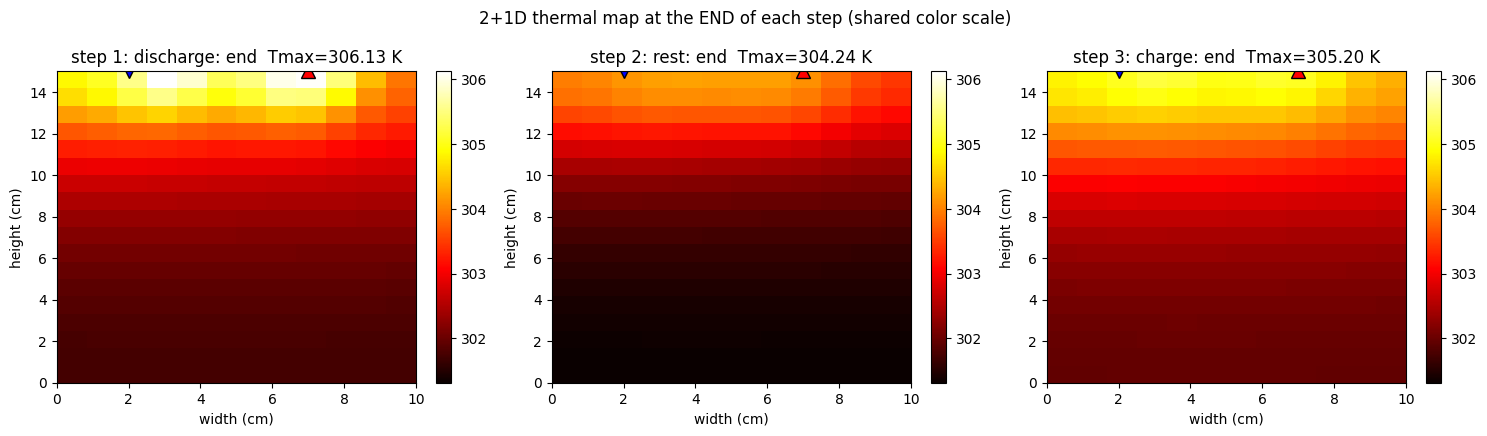

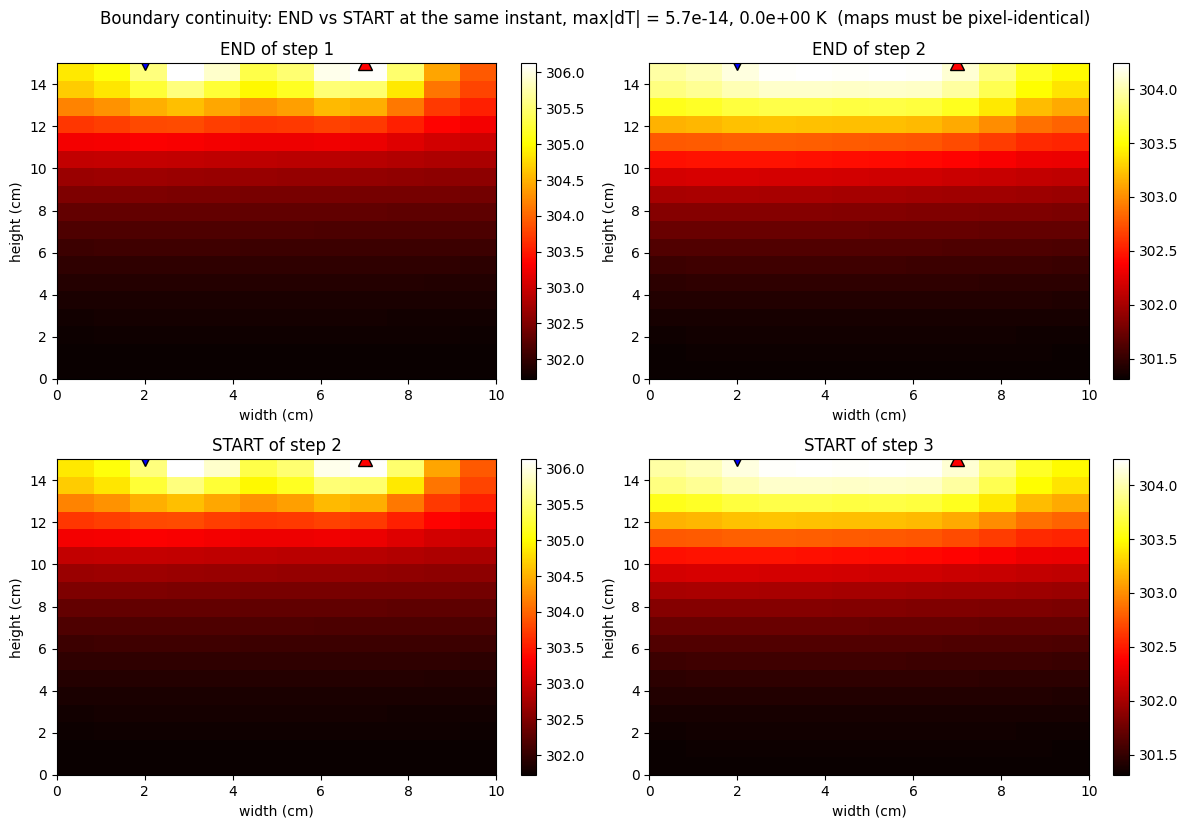

In [21]:
# ---------------------------------------------------------------
# Visual check: the 2+1D THERMAL MAP (y-z temperature field, x-lumped)
#  * Figure 1: the map at the END of each step (tab hot-spots)
#  * Figure 2: boundary continuity - END of step i vs START of step i+1.
#    These two frames are the same instant, so the two maps must look
#    pixel-identical (max|dT| ~ 1e-14 K).
# Tab markers: blue V = negative tab, red ^ = positive tab (top edge).
import numpy as np
import matplotlib.pyplot as plt

if "steps2" not in globals():
    from pouch_cell.config.design import PouchCellSpec
    from pouch_cell.config.protocol import Protocol, Step
    from pouch_cell.config.run import RunConfig
    from pouch_cell.core.experiment import run_protocol
    spec = PouchCellSpec()
    config2 = RunConfig(model_name="SPM", dimensionality=2, thermal="x-lumped",
                        mesh="micro_21d", size_to_capacity=True, particle="uniform profile")
    proto2 = Protocol(type="custom", steps=[
        Step(kind="discharge", c_rate=1.0, duration_s=10.0),
        Step(kind="rest", duration_s=5.0),
        Step(kind="charge", c_rate=0.5, duration_s=10.0),
    ], thermal_maps=False)
    _, sol2, _ = run_protocol(config2, spec, proto2)
    steps2 = sol2.cycles[0].steps

fvar = "X-averaged cell temperature [K]"
labels = ["step 1: discharge", "step 2: rest", "step 3: charge"]
y_cm = spec.width * 100    # 9 cm
z_cm = spec.height * 100   # 15 cm

def draw_map(ax, T, title, vmin, vmax):
    im = ax.imshow(T.T, origin="lower", aspect="auto",
                   extent=[0, y_cm, 0, z_cm], cmap="hot", vmin=vmin, vmax=vmax)
    ax.plot(spec.neg_tab_y_centre * 100, z_cm, "bv", ms=10, mec="k")
    ax.plot(spec.pos_tab_y_centre * 100, z_cm, "r^", ms=10, mec="k")
    ax.set_title(title)
    ax.set_xlabel("width (cm)")
    ax.set_ylabel("height (cm)")
    return im

# ---- Figure 1: thermal map at the END of each step -------------------------
ends = [np.asarray(stp[fvar].entries)[..., -1] for stp in steps2]
vmin = min(t.min() for t in ends)
vmax = max(t.max() for t in ends)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for i, T in enumerate(ends):
    im = draw_map(axes[i], T, f"{labels[i]}: end  Tmax={T.max():.2f} K", vmin, vmax)
    fig.colorbar(im, ax=axes[i], fraction=0.046)
fig.suptitle("2+1D thermal map at the END of each step (shared color scale)")
plt.tight_layout(); plt.show()

# ---- Figure 2: boundary continuity (END vs START at the same instant) -------
dmaxes = []
n = len(steps2) - 1
fig, axes = plt.subplots(2, n, figsize=(6 * n, 8.4))
for b in range(n):
    T_end = np.asarray(steps2[b][fvar].entries)[..., -1]
    T_start = np.asarray(steps2[b + 1][fvar].entries)[..., 0]
    dmax = np.abs(T_end - T_start).max()
    dmaxes.append(dmax)
    lo = min(T_end.min(), T_start.min())
    hi = max(T_end.max(), T_start.max())
    im1 = draw_map(axes[0, b], T_end, f"END of step {b+1}", lo, hi)
    im2 = draw_map(axes[1, b], T_start, f"START of step {b+2}", lo, hi)
    fig.colorbar(im1, ax=axes[0, b], fraction=0.046)
    fig.colorbar(im2, ax=axes[1, b], fraction=0.046)
fig.suptitle("Boundary continuity: END vs START at the same instant, "
             "max|dT| = " + ", ".join(f"{d:.1e}" for d in dmaxes) + " K  "
             "(maps must be pixel-identical)")
plt.tight_layout(); plt.show()
